# 06. Red neuronal para la concesión de crédito

Se entrena un perceptrón multicapa para el problema de clasificación binaria. El flujo separa entrenamiento, validación y prueba; ajusta el umbral sobre validación y estudia tanto el rendimiento como las diferencias entre grupos sensibles.

El notebook añade una lectura operativa de los errores del modelo y una estimación económica de su impacto.

**Entrada:** `data/processed/df_lasso2.csv`.


## Diseño metodológico

El proceso incluye separación de entrenamiento, validación y prueba, preprocesamiento específico para variables numéricas y categóricas, compensación del desbalance únicamente en entrenamiento, parada temprana y selección del umbral con el conjunto de validación.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 6)


In [2]:
TARGET_COL = "target"
SENSITIVE_COLS = ["sexo", "raza", "etnia"]
DROP_COLS = []

DATA_PATH = "data/processed/df_lasso2.csv"

RANDOM_STATE = 42
TEST_SIZE = 0.20
VALID_SIZE_WITHIN_TRAIN = 0.20
THRESHOLD_GRID = np.linspace(0.10, 0.90, 81)


## Carga del conjunto de datos

Se utiliza el conjunto reducido generado en la etapa LASSO.


In [3]:
if DATA_PATH is None:
    raise NameError("`DATA_PATH` no puede estar vacio en esta version del notebook.")

df_red = pd.read_csv(DATA_PATH)
df_model = df_red.copy()
df = df_model.copy()
print("Shape:", df.shape)
print("\nPrimeras columnas:")
print(df.columns.tolist())
df.head()


Shape: (2743872, 14)

Primeras columnas:
['ratio_deuda_ingresos', 'importe_prestamo', 'sistema_evaluacion_1', 'ingreso_mediano_area', 'finalidad_prestamo', 'ingresos', 'ingreso_relativo_zona', 'valor_vivienda', 'ratio_prestamo_valor', 'codigo_estado', 'sexo', 'raza', 'etnia', 'target']


,ratio_deuda_ingresos,importe_prestamo,sistema_evaluacion_1,ingreso_mediano_area,finalidad_prestamo,ingresos,ingreso_relativo_zona,valor_vivienda,ratio_prestamo_valor,codigo_estado,sexo,raza,etnia,target
0,38.0,10.915107,6,66800,31,3.713572,113.0,12.861001,69.930,PA,hombre,White,Not Hispanic or Latino,0
1,25.0,12.323860,6,97900,4,5.921578,166.0,14.224304,79.791,CA,hombre,White,Not Hispanic or Latino,1
2,33.0,13.132316,6,73100,4,6.030685,260.0,14.693061,58.638,CA,hombre,Asian,Not Hispanic or Latino,1
3,42.0,10.463132,6,64800,4,4.663439,75.0,12.524530,79.790,CA,hombre,White,Not Hispanic or Latino,1
4,55.0,11.652696,6,73100,2,4.912655,114.0,14.190517,29.235,CA,hombre,White,Not Hispanic or Latino,1


## Helpers

Estas funciones mantienen el notebook limpio y reproducible.


In [4]:
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def normalize_binary_target(series):
    values = sorted(pd.Series(series).dropna().unique().tolist())
    if values not in ([0, 1], [0], [1]):
        raise ValueError(f"La variable objetivo debe ser binaria. Valores encontrados: {values}")
    return series.astype(int)


def build_feature_lists(frame, target_col, drop_cols=None):
    drop_cols = drop_cols or []
    feature_cols = [c for c in frame.columns if c not in [target_col] + drop_cols]
    numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(frame[c])]
    categorical_cols = [c for c in feature_cols if c not in numeric_cols]
    return feature_cols, numeric_cols, categorical_cols


def oversample_minority(X_array, y_array, random_state=42):
    rng = np.random.default_rng(random_state)
    y_array = np.asarray(y_array)
    classes, counts = np.unique(y_array, return_counts=True)
    if len(classes) != 2:
        return X_array, y_array

    minority_class = classes[np.argmin(counts)]
    n_to_add = counts.max() - counts.min()

    if n_to_add == 0:
        return X_array, y_array

    minority_idx = np.where(y_array == minority_class)[0]
    sampled_idx = rng.choice(minority_idx, size=n_to_add, replace=True)

    X_balanced = np.vstack([X_array, X_array[sampled_idx]])
    y_balanced = np.concatenate([y_array, y_array[sampled_idx]])

    order = rng.permutation(len(y_balanced))
    return X_balanced[order], y_balanced[order]


def threshold_metrics(y_true, y_prob, grid):
    rows = []
    for thr in grid:
        pred = (y_prob >= thr).astype(int)
        rows.append(
            {
                "threshold": thr,
                "f1": f1_score(y_true, pred, zero_division=0),
                "precision": precision_score(y_true, pred, zero_division=0),
                "recall": recall_score(y_true, pred, zero_division=0),
                "balanced_accuracy": balanced_accuracy_score(y_true, pred),
                "accuracy": accuracy_score(y_true, pred),
            }
        )
    return pd.DataFrame(rows)


def summarize_predictions(y_true, y_prob, threshold):
    pred = (y_prob >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "f1": f1_score(y_true, pred, zero_division=0),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
    }


def safe_group_metric(frame, group_col, target_col, pred_col):
    out = []
    for group_value, g in frame.groupby(group_col, observed=False):
        y_true = g[target_col].to_numpy()
        y_pred = g[pred_col].to_numpy()

        tp = int(((y_true == 1) & (y_pred == 1)).sum())
        tn = int(((y_true == 0) & (y_pred == 0)).sum())
        fp = int(((y_true == 0) & (y_pred == 1)).sum())
        fn = int(((y_true == 1) & (y_pred == 0)).sum())

        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

        out.append(
            {
                group_col: group_value,
                "n": len(g),
                "base_rate": g[target_col].mean(),
                "predicted_positive_rate": g[pred_col].mean(),
                "mean_probability": g["prob_target_1"].mean(),
                "TPR": tpr,
                "FPR": fpr,
                "precision": precision,
            }
        )

    return pd.DataFrame(out).sort_values("n", ascending=False)


## Auditoría inicial del conjunto de datos


In [5]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
audit_table = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=False),
    }
).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

display(audit_table)


,dtype,missing_pct,n_unique
ratio_prestamo_valor,float64,0.0,94982
ingreso_relativo_zona,float64,0.0,20117
ingresos,float64,0.0,5682
valor_vivienda,float64,0.0,1401
importe_prestamo,float64,0.0,975
ingreso_mediano_area,int64,0.0,739
codigo_estado,str,0.0,52
ratio_deuda_ingresos,float64,0.0,19
sistema_evaluacion_1,int64,0.0,7
finalidad_prestamo,int64,0.0,6


## Preparacion y particion del dataset


In [6]:
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns]).copy()
df[TARGET_COL] = normalize_binary_target(df[TARGET_COL])

feature_cols, numeric_cols, categorical_cols = build_feature_lists(df, TARGET_COL)
sensitive_cols = [c for c in SENSITIVE_COLS if c in df.columns]

X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VALID_SIZE_WITHIN_TRAIN,
    random_state=RANDOM_STATE,
    stratify=y_train_full,
)

print("Train:", X_train.shape, y_train.mean())
print("Validation:", X_valid.shape, y_valid.mean())
print("Test:", X_test.shape, y_test.mean())
print("\nSensibles detectadas:", sensitive_cols)
print("Numericas:", len(numeric_cols))
print("Categoricas:", len(categorical_cols))


Train: (1756077, 13) 0.638694089154405
Validation: (439020, 13) 0.6386952758416473
Test: (548775, 13) 0.6386952758416473

Sensibles detectadas: ['sexo', 'raza', 'etnia']
Numericas: 9
Categoricas: 4


In [7]:
numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_ohe()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ],
    remainder="drop",
)

X_train_proc = preprocessor.fit_transform(X_train)
X_valid_proc = preprocessor.transform(X_valid)
X_test_proc = preprocessor.transform(X_test)
X_all_proc = preprocessor.transform(X)

X_train_bal, y_train_bal = oversample_minority(X_train_proc, y_train.to_numpy(), random_state=RANDOM_STATE)
feature_names_out = preprocessor.get_feature_names_out()

print("Train procesado:", X_train_proc.shape)
print("Train balanceado:", X_train_bal.shape)
print("Validation procesado:", X_valid_proc.shape)
print("Test procesado:", X_test_proc.shape)


Train procesado: (1756077, 74)
Train balanceado: (2243192, 74)
Validation procesado: (439020, 74)
Test procesado: (548775, 74)


## Arquitectura de la red neuronal

La configuracion esta pensada para que la red sea expresiva, pero sin volverse dificil de justificar:
- tres capas ocultas decrecientes
- activacion `relu`
- optimizador `adam`
- regularizacion L2
- `early_stopping` para limitar sobreajuste


In [8]:
model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate="adaptive",
    learning_rate_init=0.001,
    alpha=0.001,
    batch_size=256,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=20,
    random_state=RANDOM_STATE,
    verbose=True,
)

model.fit(X_train_bal, y_train_bal)
print("Iteraciones realizadas:", model.n_iter_)


Iteration 1, loss = 0.35485088
Validation score: 0.847223
Iteration 2, loss = 0.33290842
Validation score: 0.851493
Iteration 3, loss = 0.32665234
Validation score: 0.854284
Iteration 4, loss = 0.32374688
Validation score: 0.854979
Iteration 5, loss = 0.32191093
Validation score: 0.855193
Iteration 6, loss = 0.32048161
Validation score: 0.855613
Iteration 7, loss = 0.31937233
Validation score: 0.856375
Iteration 8, loss = 0.31844155
Validation score: 0.856780
Iteration 9, loss = 0.31772862
Validation score: 0.855733
Iteration 10, loss = 0.31695833
Validation score: 0.856709
Iteration 11, loss = 0.31638482
Validation score: 0.857614
Iteration 12, loss = 0.31570597
Validation score: 0.857324
Iteration 13, loss = 0.31511146
Validation score: 0.858604
Iteration 14, loss = 0.31456106
Validation score: 0.858408
Iteration 15, loss = 0.31411057
Validation score: 0.857931
Iteration 16, loss = 0.31364773
Validation score: 0.858974
Iteration 17, loss = 0.31316022
Validation score: 0.859063
Iterat

## Ajuste del umbral en validacion

Para un TFM queda mejor no fijar automaticamente el umbral en `0.5`.
Aqui se selecciona el threshold que maximiza `F1` en validation.


In [9]:
y_prob_train = model.predict_proba(X_train_proc)[:, 1]
y_prob_valid = model.predict_proba(X_valid_proc)[:, 1]
y_prob_test = model.predict_proba(X_test_proc)[:, 1]

threshold_table = threshold_metrics(y_valid, y_prob_valid, THRESHOLD_GRID)
best_row = threshold_table.sort_values(
    ["f1", "recall", "precision", "threshold"],
    ascending=[False, False, False, True],
).iloc[0]
best_threshold = float(best_row["threshold"])

print(f"Threshold optimo en validation: {best_threshold:.3f}")
display(threshold_table.sort_values("f1", ascending=False).head(10))


Threshold optimo en validation: 0.300


,threshold,f1,precision,recall,balanced_accuracy,accuracy
20,0.30,0.906128,0.868178,0.947546,0.846608,0.874607
19,0.29,0.906097,0.865806,0.950321,0.844972,0.874195
17,0.27,0.906035,0.861192,0.955806,0.841735,0.873377
18,0.28,0.906009,0.863377,0.953071,0.843232,0.873701
21,0.31,0.905888,0.870260,0.944558,0.847815,0.874650
16,0.26,0.905882,0.858813,0.958409,0.839941,0.872803
22,0.32,0.905753,0.872487,0.941655,0.849188,0.874837
23,0.33,0.905568,0.874620,0.938787,0.850443,0.874949
15,0.25,0.905532,0.856238,0.960849,0.837832,0.871956
24,0.34,0.905264,0.876778,0.935663,0.851604,0.874921


In [10]:
y_pred_train = (y_prob_train >= best_threshold).astype(int)
y_pred_valid = (y_prob_valid >= best_threshold).astype(int)
y_pred_test = (y_prob_test >= best_threshold).astype(int)

metrics_df = pd.DataFrame(
    {
        "train": summarize_predictions(y_train, y_prob_train, best_threshold),
        "validation": summarize_predictions(y_valid, y_prob_valid, best_threshold),
        "test": summarize_predictions(y_test, y_prob_test, best_threshold),
    }
).T

metrics_df


,roc_auc,pr_auc,brier,f1,precision,recall,accuracy,balanced_accuracy
train,0.940917,0.958654,0.092424,0.909000,0.871296,0.950116,0.878500,0.851009
validation,0.936632,0.954595,0.095516,0.906128,0.868178,0.947546,0.874607,0.846608
test,0.936268,0.954477,0.095943,0.905497,0.867684,0.946756,0.873783,0.845770


## Diagnostico visual del modelo


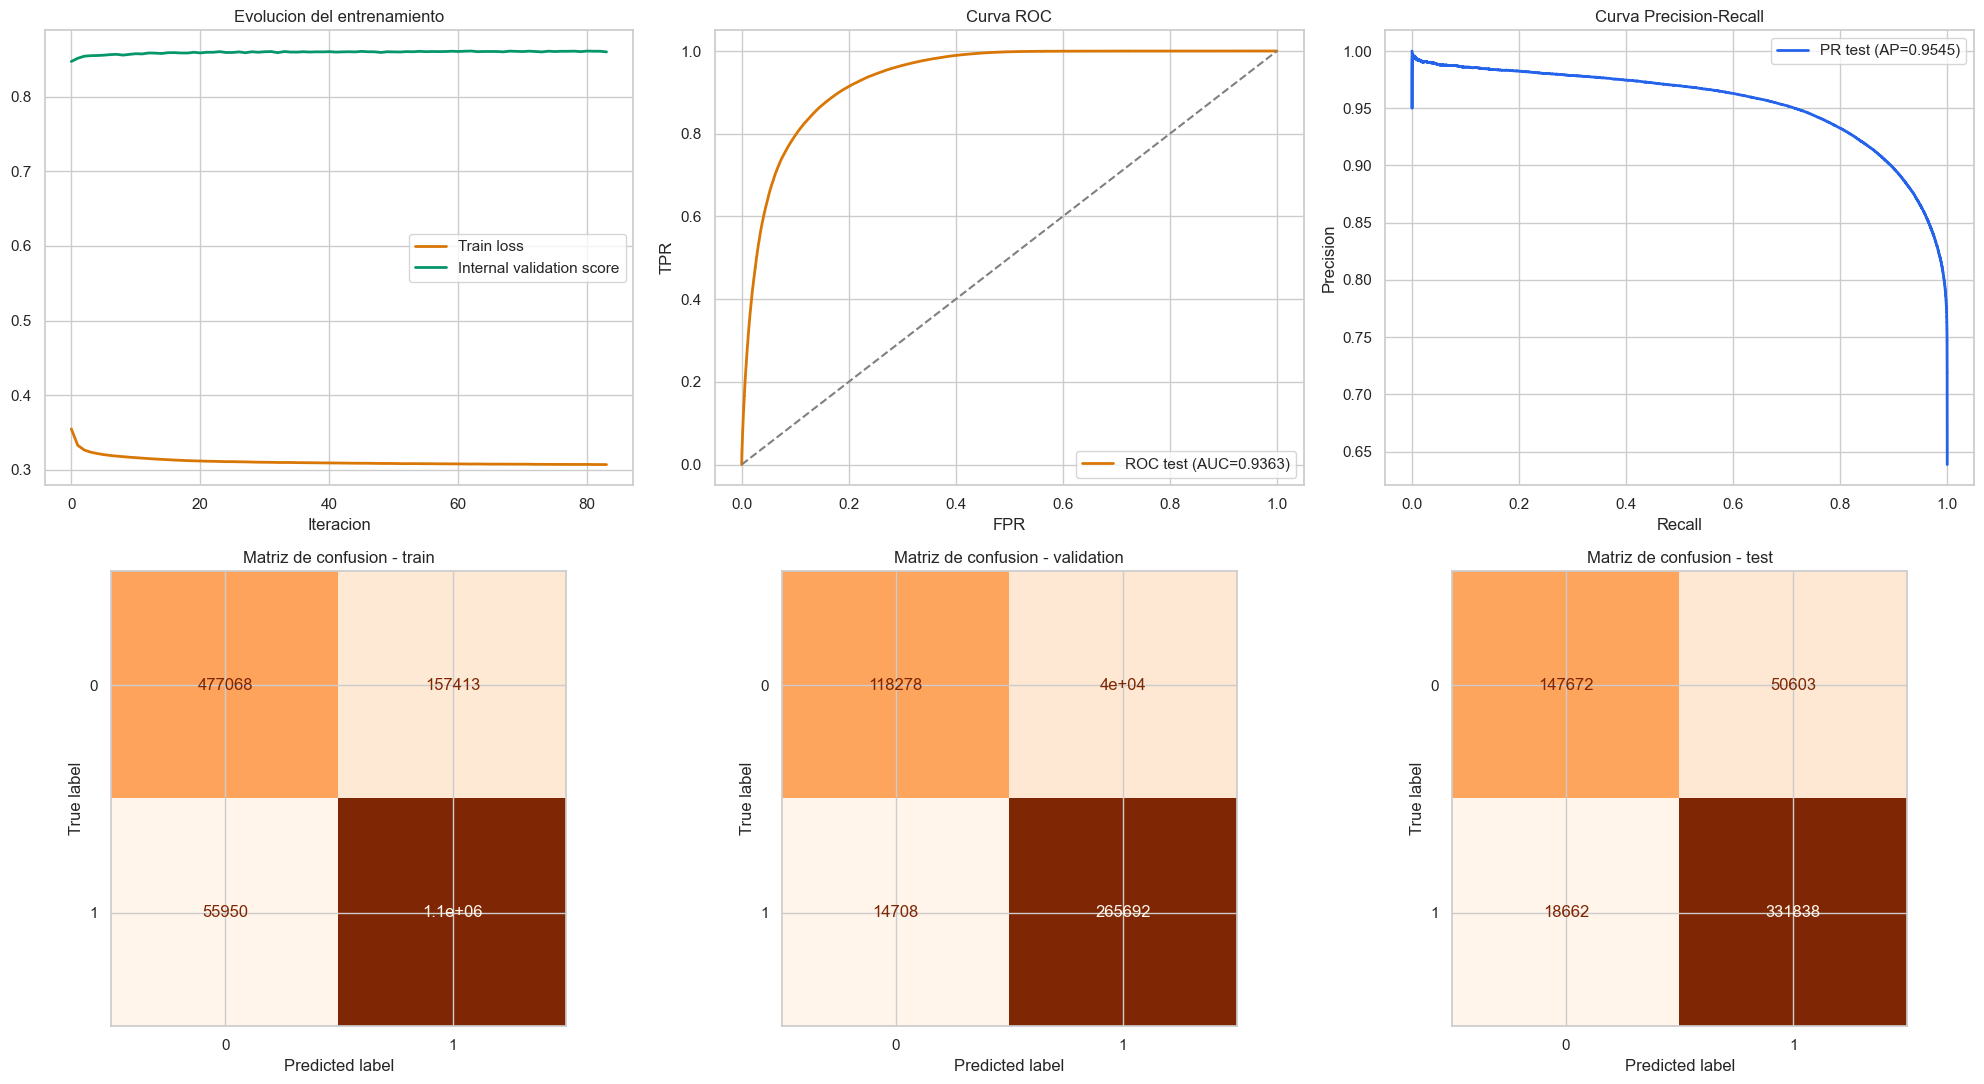

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

axes[0, 0].plot(model.loss_curve_, color="#d97706", lw=2, label="Train loss")
if getattr(model, "validation_scores_", None):
    axes[0, 0].plot(model.validation_scores_, color="#059669", lw=2, label="Internal validation score")
axes[0, 0].set_title("Evolucion del entrenamiento")
axes[0, 0].set_xlabel("Iteracion")
axes[0, 0].legend()

fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[0, 1].plot(fpr, tpr, color="#d97706", lw=2, label=f"ROC test (AUC={roc_auc_score(y_test, y_prob_test):.4f})")
axes[0, 1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0, 1].set_title("Curva ROC")
axes[0, 1].set_xlabel("FPR")
axes[0, 1].set_ylabel("TPR")
axes[0, 1].legend()

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob_test)
axes[0, 2].plot(recall_vals, precision_vals, color="#2563eb", lw=2, label=f"PR test (AP={average_precision_score(y_test, y_prob_test):.4f})")
axes[0, 2].set_title("Curva Precision-Recall")
axes[0, 2].set_xlabel("Recall")
axes[0, 2].set_ylabel("Precision")
axes[0, 2].legend()

ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train, cmap="Oranges", ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title("Matriz de confusion - train")

ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_valid, cmap="Oranges", ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title("Matriz de confusion - validation")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap="Oranges", ax=axes[1, 2], colorbar=False)
axes[1, 2].set_title("Matriz de confusion - test")

plt.tight_layout()
plt.show()


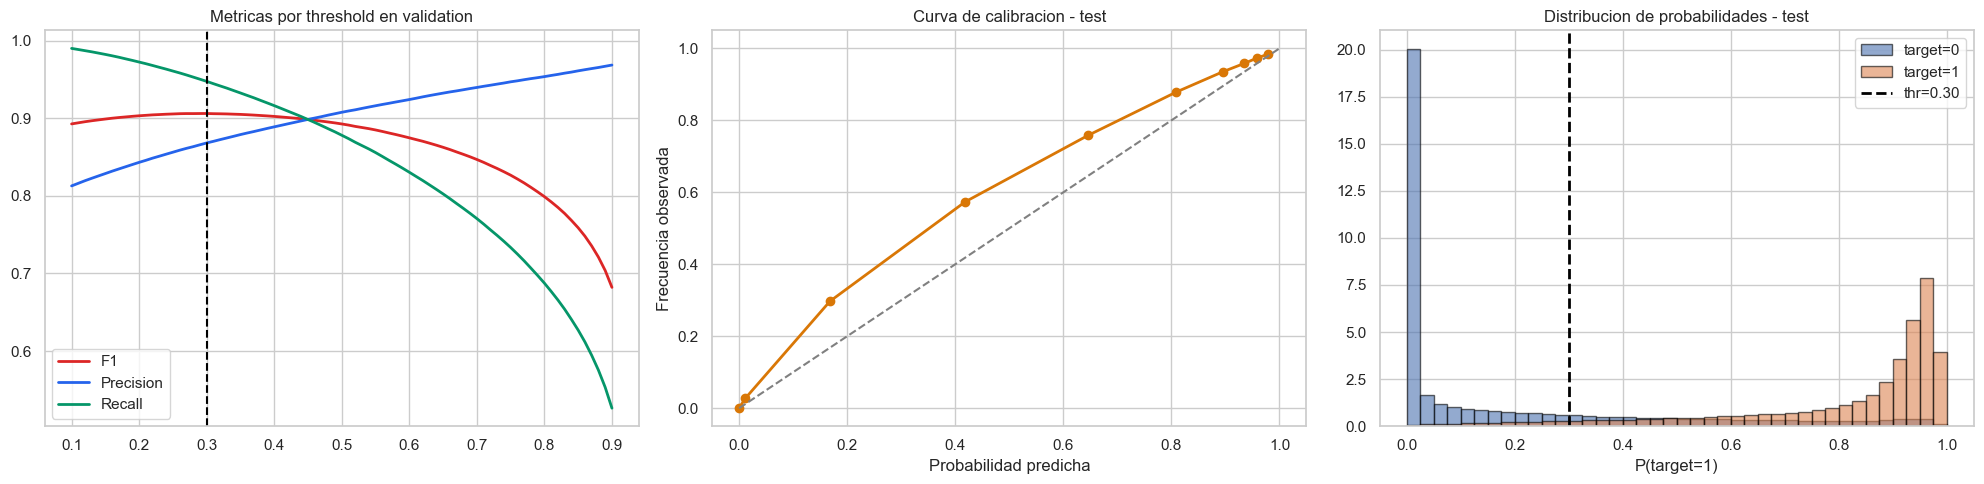

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

thr_plot = threshold_table.copy()
axes[0].plot(thr_plot["threshold"], thr_plot["f1"], label="F1", color="#dc2626", lw=2)
axes[0].plot(thr_plot["threshold"], thr_plot["precision"], label="Precision", color="#2563eb", lw=2)
axes[0].plot(thr_plot["threshold"], thr_plot["recall"], label="Recall", color="#059669", lw=2)
axes[0].axvline(best_threshold, color="black", linestyle="--")
axes[0].set_title("Metricas por threshold en validation")
axes[0].legend()

prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")
axes[1].plot(prob_pred, prob_true, marker="o", color="#d97706", lw=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("Curva de calibracion - test")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_ylabel("Frecuencia observada")

axes[2].hist(y_prob_test[y_test == 0], bins=40, alpha=0.6, density=True, label="target=0", edgecolor="black")
axes[2].hist(y_prob_test[y_test == 1], bins=40, alpha=0.6, density=True, label="target=1", edgecolor="black")
axes[2].axvline(best_threshold, color="black", linestyle="--", linewidth=2, label=f"thr={best_threshold:.2f}")
axes[2].set_title("Distribucion de probabilidades - test")
axes[2].set_xlabel("P(target=1)")
axes[2].legend()

plt.tight_layout()
plt.show()


In [13]:
print("--- TRAIN ---")
print(classification_report(y_train, y_pred_train, zero_division=0))

print("--- VALIDATION ---")
print(classification_report(y_valid, y_pred_valid, zero_division=0))

print("--- TEST ---")
print(classification_report(y_test, y_pred_test, zero_division=0))

gap_auc = metrics_df.loc["train", "roc_auc"] - metrics_df.loc["test", "roc_auc"]
print(f"Gap AUC train-test: {gap_auc:.4f}")
if gap_auc < 0.03:
    print("Diagnostico: sobreajuste bajo.")
elif gap_auc < 0.05:
    print("Diagnostico: sobreajuste leve.")
else:
    print("Diagnostico: sobreajuste relevante. Revisa arquitectura, alpha o threshold.")


--- TRAIN ---
              precision    recall  f1-score   support

           0       0.90      0.75      0.82    634481
           1       0.87      0.95      0.91   1121596

    accuracy                           0.88   1756077
   macro avg       0.88      0.85      0.86   1756077
weighted avg       0.88      0.88      0.88   1756077

--- VALIDATION ---
              precision    recall  f1-score   support

           0       0.89      0.75      0.81    158620
           1       0.87      0.95      0.91    280400

    accuracy                           0.87    439020
   macro avg       0.88      0.85      0.86    439020
weighted avg       0.88      0.87      0.87    439020

--- TEST ---
              precision    recall  f1-score   support

           0       0.89      0.74      0.81    198275
           1       0.87      0.95      0.91    350500

    accuracy                           0.87    548775
   macro avg       0.88      0.85      0.86    548775
weighted avg       0.87     

## Importancia aproximada de variables

En redes neuronales la interpretabilidad no es tan directa como en arboles. Como aproximacion simple, se resume el peso medio absoluto de la primera capa.


,feature,importance
2,num__sistema_evaluacion_1,0.445177
8,num__ratio_prestamo_valor,0.388069
0,num__ratio_deuda_ingresos,0.370700
43,cat__codigo_estado_NY,0.351944
7,num__valor_vivienda,0.328933
54,cat__codigo_estado_UT,0.323619
32,cat__codigo_estado_MN,0.319600
15,cat__codigo_estado_CT,0.316048
1,num__importe_prestamo,0.314563
42,cat__codigo_estado_NV,0.312656


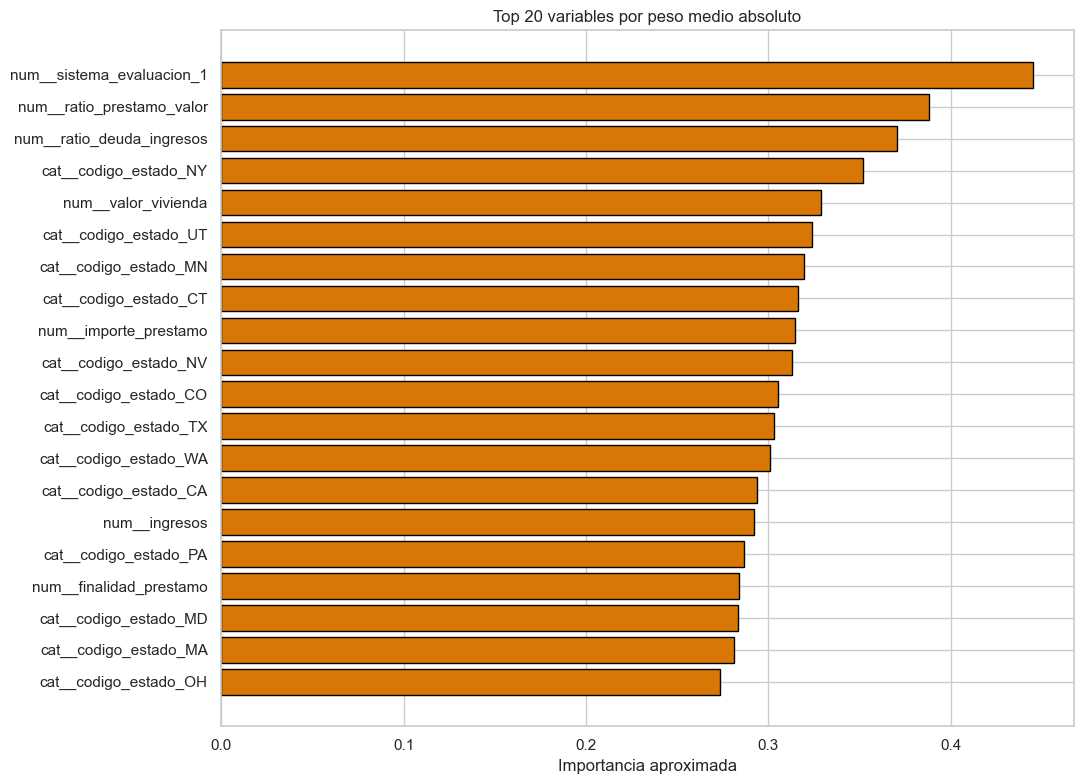

In [14]:
first_layer_importance = np.abs(model.coefs_[0]).mean(axis=1)
importance_df = pd.DataFrame(
    {
        "feature": feature_names_out,
        "importance": first_layer_importance,
    }
).sort_values("importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(11, 8))
top_imp = importance_df.head(20).sort_values("importance")
plt.barh(top_imp["feature"], top_imp["importance"], color="#d97706", edgecolor="black")
plt.title("Top 20 variables por peso medio absoluto")
plt.xlabel("Importancia aproximada")
plt.tight_layout()
plt.show()


## Analisis de sesgo por grupos sensibles

Esta parte te deja una base muy util para la seccion de fairness del TFM. Se reportan:
- tasa real de `target=1`
- tasa predicha positiva
- probabilidad media
- TPR
- FPR
- precision


In [15]:
test_eval = X_test.copy()
test_eval[TARGET_COL] = y_test.values
test_eval["prob_target_1"] = y_prob_test
test_eval["pred_target_1"] = y_pred_test

for col in sensitive_cols:
    test_eval[col] = test_eval[col].fillna("Missing")
    print(f"\n=== Fairness summary por {col} ===")
    display(safe_group_metric(test_eval, col, TARGET_COL, "pred_target_1"))



=== Fairness summary por sexo ===


,sexo,n,base_rate,predicted_positive_rate,mean_probability,TPR,FPR,precision
0,hombre,328806,0.648586,0.709896,0.589671,0.947608,0.271162,0.865769
1,mujer,219969,0.623911,0.677473,0.570729,0.945432,0.232944,0.870684



=== Fairness summary por raza ===


,raza,n,base_rate,predicted_positive_rate,mean_probability,TPR,FPR,precision
5,White,406098,0.658553,0.720055,0.599834,0.950856,0.274908,0.869640
2,Asian,72632,0.679370,0.740555,0.634709,0.961799,0.271771,0.882334
3,Black or African American,59910,0.490970,0.527491,0.433219,0.895628,0.172416,0.833618
1,American Indian or Alaska Native,5599,0.439721,0.469727,0.387300,0.874898,0.151737,0.819011
4,Native Hawaiian or Other Pacific Islander,2658,0.384876,0.431151,0.337091,0.863148,0.160856,0.770506
0,2 or more minority races,1878,0.436635,0.458999,0.383397,0.858537,0.149338,0.816705



=== Fairness summary por etnia ===


,etnia,n,base_rate,predicted_positive_rate,mean_probability,TPR,FPR,precision
4,Not Hispanic or Latino,459927,0.663027,0.726139,0.606752,0.953008,0.279753,0.870177
2,Hispanic or Latino,69965,0.523362,0.556850,0.464250,0.909550,0.169575,0.854851
0,Ethnicity Not Available,13940,0.476686,0.507891,0.417320,0.883371,0.165867,0.829096
3,Joint,2695,0.530241,0.561781,0.474495,0.904129,0.175355,0.853369
1,Free Form Text Only,2248,0.384786,0.407473,0.351907,0.875145,0.114967,0.826419


## Scoring completo del dataset y buckets de riesgo

Esto te sirve tanto para visualizacion final como para narrativa de segmentacion del riesgo.


In [16]:
df_scored = df.copy()
df_scored["prob_target_1"] = model.predict_proba(X_all_proc)[:, 1]
df_scored["pred_target_1"] = (df_scored["prob_target_1"] >= best_threshold).astype(int)

df_scored["bucket_prob"] = pd.cut(
    df_scored["prob_target_1"],
    bins=[-0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    labels=[
        "0-10%", "10-20%", "20-30%", "30-40%", "40-50%",
        "50-60%", "60-70%", "70-80%", "80-90%", "90-100%",
    ],
)

bucket_summary = df_scored.groupby("bucket_prob", observed=False).agg(
    n=(TARGET_COL, "size"),
    num_target_1=(TARGET_COL, "sum"),
    mean_prob=("prob_target_1", "mean"),
).assign(
    num_target_0=lambda x: x["n"] - x["num_target_1"],
    pct_target_1=lambda x: (100 * x["num_target_1"] / x["n"]).round(2),
    pct_total=lambda x: (100 * x["n"] / x["n"].sum()).round(2),
).fillna(0)

display(bucket_summary)


,n,num_target_1,mean_prob,num_target_0,pct_target_1,pct_total
bucket_prob,,,,,,
0-10%,609395,16162,0.012947,593233,2.65,22.21
10-20%,113931,30207,0.149190,83724,26.51,4.15
20-30%,109012,42951,0.249742,66061,39.40,3.97
30-40%,106470,54208,0.349950,52262,50.91,3.88
40-50%,110733,66909,0.450726,43824,60.42,4.04
50-60%,120684,83323,0.550848,37361,69.04,4.40
60-70%,137495,105418,0.651322,32077,76.67,5.01
70-80%,174220,146670,0.752610,27550,84.19,6.35
80-90%,312777,285613,0.857921,27164,91.32,11.40


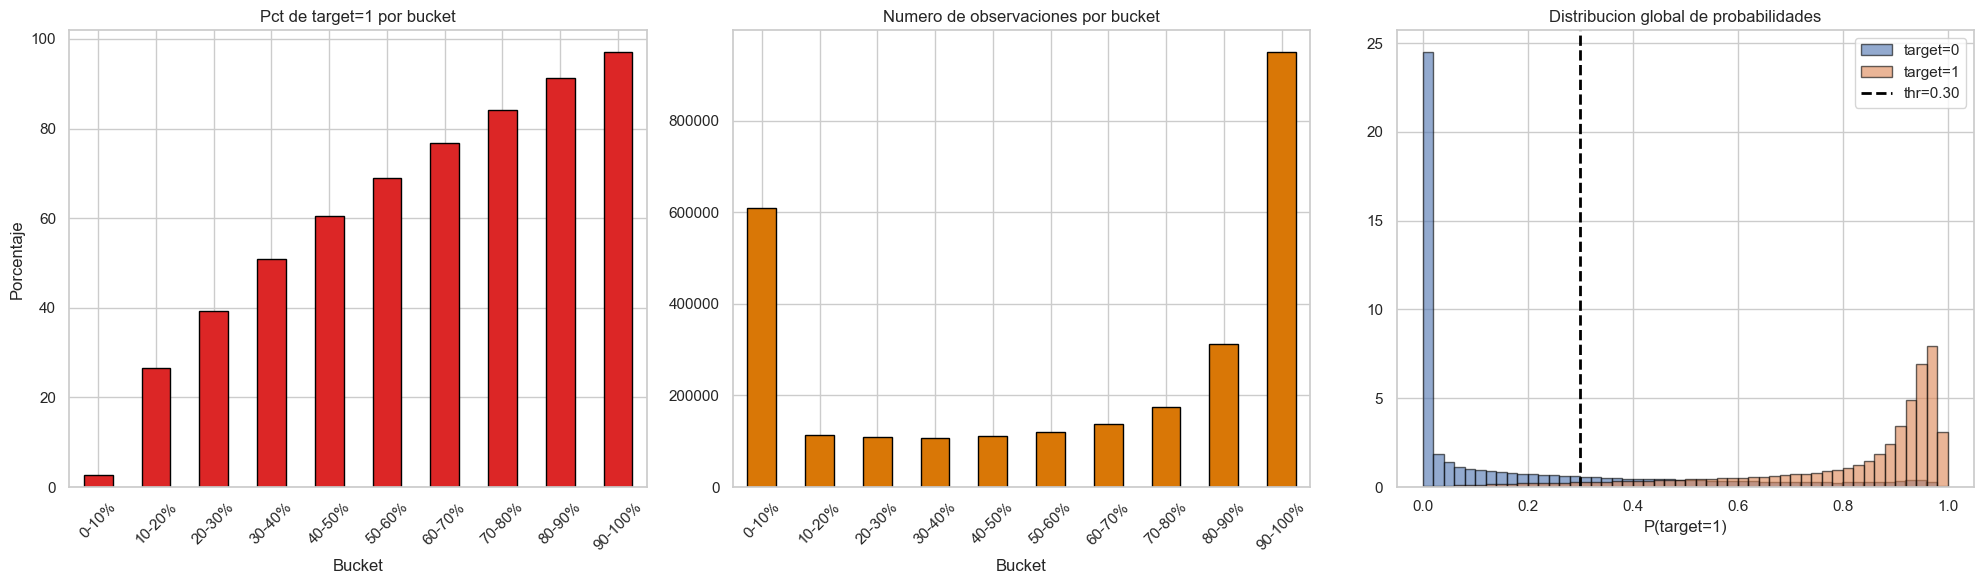

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

bucket_summary["pct_target_1"].plot(kind="bar", ax=axes[0], color="#dc2626", edgecolor="black")
axes[0].set_title("Pct de target=1 por bucket")
axes[0].set_xlabel("Bucket")
axes[0].set_ylabel("Porcentaje")
axes[0].tick_params(axis="x", rotation=45)

bucket_summary["n"].plot(kind="bar", ax=axes[1], color="#d97706", edgecolor="black")
axes[1].set_title("Numero de observaciones por bucket")
axes[1].set_xlabel("Bucket")
axes[1].tick_params(axis="x", rotation=45)

axes[2].hist(df_scored.loc[df_scored[TARGET_COL] == 0, "prob_target_1"], bins=50, alpha=0.6, label="target=0", density=True, edgecolor="black")
axes[2].hist(df_scored.loc[df_scored[TARGET_COL] == 1, "prob_target_1"], bins=50, alpha=0.6, label="target=1", density=True, edgecolor="black")
axes[2].axvline(best_threshold, color="black", linestyle="--", linewidth=2, label=f"thr={best_threshold:.2f}")
axes[2].set_title("Distribucion global de probabilidades")
axes[2].set_xlabel("P(target=1)")
axes[2].legend()

plt.tight_layout()
plt.show()


## Valor operativo y economico del modelo

Esta seccion traduce la salida probabilistica de la red neuronal a una logica de decision gradual. La idea no es quedarse solo en la clasificacion binaria, sino estimar como los `buckets` de riesgo pueden apoyar politicas de concesion, revision manual y priorizacion, incorporando ademas una aproximacion prudente del coste de oportunidad.


In [18]:
# Parametros economicos de referencia obtenidos en el notebook `analisis-2`
INTEREST_RATE_MEAN = 2.6734427684673334
LOAN_TERM_MEAN = 28.49563649470529

test_business = test_eval.copy()
test_business["bucket_prob"] = pd.cut(
    test_business["prob_target_1"],
    bins=[-0.001, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"],
)

test_business["decision_policy"] = pd.cut(
    test_business["prob_target_1"],
    bins=[-0.001, 0.2, 0.4, 0.6, 1.0],
    labels=[
        "Aprobacion casi automatica",
        "Revision ligera",
        "Revision manual reforzada",
        "Politica conservadora",
    ],
)

loan_amount_col = "importe_prestamo" if "importe_prestamo" in test_business.columns else None

if loan_amount_col is not None:
    # Si el importe esta log-transformado, lo devolvemos aproximadamente a dolares.
    if test_business[loan_amount_col].dropna().abs().max() < 50:
        test_business["loan_amount_est"] = np.exp(test_business[loan_amount_col])
    else:
        test_business["loan_amount_est"] = test_business[loan_amount_col]
else:
    test_business["loan_amount_est"] = np.nan

bucket_business_summary = test_business.groupby(["bucket_prob", "decision_policy"], observed=False).agg(
    n=(TARGET_COL, "size"),
    positives=(TARGET_COL, "sum"),
    mean_prob=("prob_target_1", "mean"),
    mean_loan_amount=("loan_amount_est", "mean"),
    total_loan_amount=("loan_amount_est", "sum"),
).assign(
    positive_rate=lambda x: (100 * x["positives"] / x["n"]).round(2),
).fillna(0)

display(bucket_business_summary.reset_index())


,bucket_prob,decision_policy,n,positives,mean_prob,mean_loan_amount,total_loan_amount,positive_rate
0,0-20%,Aprobacion casi automatica,144641,9936,0.034382,163801.616699,2.369243e+10,6.87
1,0-20%,Revision ligera,0,0,0.000000,0.000000,0.000000e+00,0.00
2,0-20%,Revision manual reforzada,0,0,0.000000,0.000000,0.000000e+00,0.00
3,0-20%,Politica conservadora,0,0,0.000000,0.000000,0.000000e+00,0.00
4,20-40%,Aprobacion casi automatica,0,0,0.000000,0.000000,0.000000e+00,0.00
5,20-40%,Revision ligera,43217,19694,0.299538,162333.762570,7.015578e+09,45.57
6,20-40%,Revision manual reforzada,0,0,0.000000,0.000000,0.000000e+00,0.00
7,20-40%,Politica conservadora,0,0,0.000000,0.000000,0.000000e+00,0.00
8,40-60%,Aprobacion casi automatica,0,0,0.000000,0.000000,0.000000e+00,0.00
9,40-60%,Revision ligera,0,0,0.000000,0.000000,0.000000e+00,0.00


In [19]:
# Falsos negativos y aproximacion al coste de oportunidad
# La interpretacion economica supone que `target=1` representa la clase de interes para conceder o captar.

false_negatives = test_business[(test_business[TARGET_COL] == 1) & (test_business["pred_target_1"] == 0)].copy()

if len(false_negatives) == 0:
    print("No hay falsos negativos con el umbral actual.")
else:
    false_negatives["opportunity_cost_est"] = (
        false_negatives["loan_amount_est"] *
        (INTEREST_RATE_MEAN / 100) *
        LOAN_TERM_MEAN
    )

    fn_summary = pd.DataFrame(
        {
            "metric": [
                "Total falsos negativos",
                "Importe medio estimado",
                "Importe total potencial no concedido",
                "Coste de oportunidad total estimado",
                "Coste de oportunidad medio por FN",
            ],
            "value": [
                len(false_negatives),
                false_negatives["loan_amount_est"].mean(),
                false_negatives["loan_amount_est"].sum(),
                false_negatives["opportunity_cost_est"].sum(),
                false_negatives["opportunity_cost_est"].mean(),
            ],
        }
    )
    display(fn_summary)


,metric,value
0,Total falsos negativos,1.866200e+04
1,Importe medio estimado,1.631995e+05
2,Importe total potencial no concedido,3.045629e+09
3,Coste de oportunidad total estimado,2.320204e+09
4,Coste de oportunidad medio por FN,1.243277e+05


In [20]:
# Valor esperado aproximado por umbral
# Ajusta estas magnitudes si quieres endurecer o suavizar la politica economica.
BENEFIT_TRUE_POSITIVE = 1.00
COST_FALSE_POSITIVE = 1.50
COST_FALSE_NEGATIVE = 0.75

business_rows = []
for thr in THRESHOLD_GRID:
    pred_thr = (y_prob_test >= thr).astype(int)
    tp = int(((y_test.values == 1) & (pred_thr == 1)).sum())
    tn = int(((y_test.values == 0) & (pred_thr == 0)).sum())
    fp = int(((y_test.values == 0) & (pred_thr == 1)).sum())
    fn = int(((y_test.values == 1) & (pred_thr == 0)).sum())

    business_value = (tp * BENEFIT_TRUE_POSITIVE) - (fp * COST_FALSE_POSITIVE) - (fn * COST_FALSE_NEGATIVE)
    business_rows.append({
        "threshold": thr,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "f1": f1_score(y_test, pred_thr, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred_thr),
        "business_value": business_value,
    })

business_threshold_df = pd.DataFrame(business_rows)
display(business_threshold_df.sort_values("business_value", ascending=False).head(10))

best_business_row = business_threshold_df.sort_values(["business_value", "f1"], ascending=[False, False]).iloc[0]
print(f"Threshold con mayor valor esperado: {best_business_row['threshold']:.3f}")
print(f"Valor esperado aproximado: {best_business_row['business_value']:.2f}")
print(f"F1 asociado: {best_business_row['f1']:.4f}")
print(f"Balanced accuracy asociada: {best_business_row['balanced_accuracy']:.4f}")


,threshold,tp,tn,fp,fn,f1,balanced_accuracy,business_value
20,0.30,331838,147672,50603,18662,0.905497,0.845770,241937.00
19,0.29,332791,146545,51730,17709,0.905528,0.844287,241914.25
21,0.31,330777,148892,49383,19723,0.905420,0.847333,241910.25
22,0.32,329776,150042,48233,20724,0.905345,0.848805,241883.50
23,0.33,328811,151158,47117,21689,0.905282,0.850243,241868.75
18,0.28,333753,145352,52923,16747,0.905491,0.842651,241808.25
17,0.27,334677,144176,54099,15823,0.905418,0.841004,241661.25
24,0.34,327747,152229,46046,22753,0.905012,0.851426,241613.25
16,0.26,335594,142921,55354,14906,0.905239,0.839147,241383.50
25,0.35,326618,153252,45023,23882,0.904582,0.852395,241172.00


Threshold con mayor valor esperado: 0.300
Valor esperado aproximado: 241937.00
F1 asociado: 0.9055
Balanced accuracy asociada: 0.8458


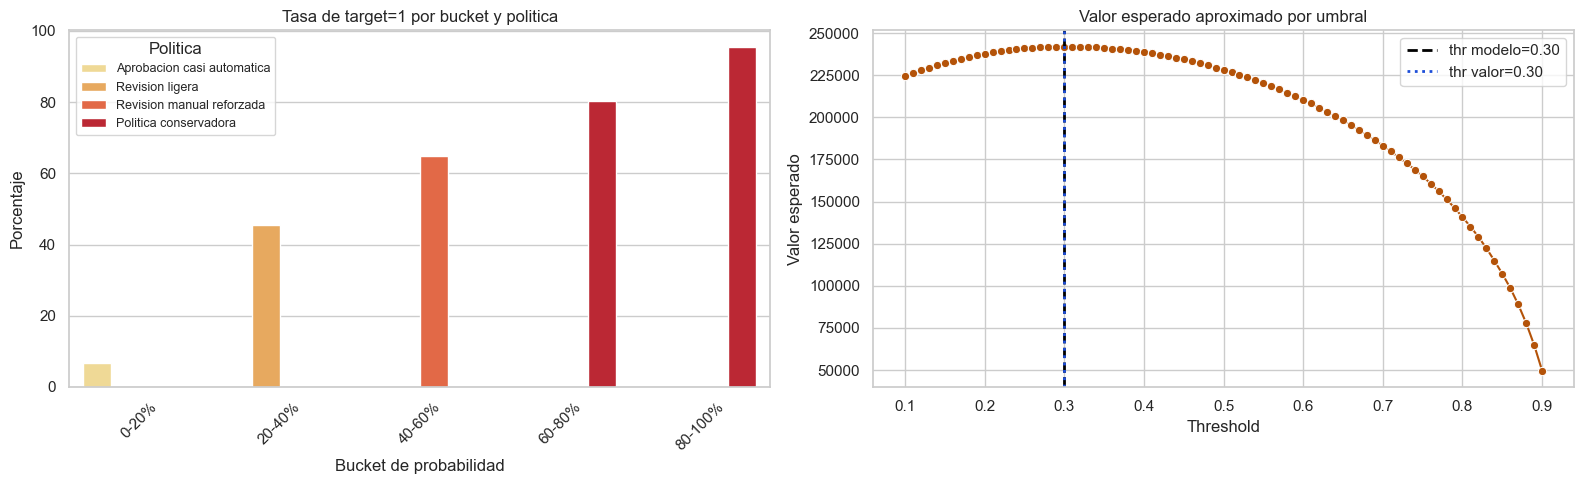

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bucket_plot = bucket_business_summary.reset_index()
sns.barplot(data=bucket_plot, x="bucket_prob", y="positive_rate", hue="decision_policy", ax=axes[0], palette="YlOrRd")
axes[0].set_title("Tasa de target=1 por bucket y politica")
axes[0].set_xlabel("Bucket de probabilidad")
axes[0].set_ylabel("Porcentaje")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Politica", fontsize=9)

sns.lineplot(data=business_threshold_df, x="threshold", y="business_value", marker="o", ax=axes[1], color="#b45309")
axes[1].axvline(best_threshold, color="black", linestyle="--", linewidth=2, label=f"thr modelo={best_threshold:.2f}")
axes[1].axvline(best_business_row["threshold"], color="#1d4ed8", linestyle=":", linewidth=2, label=f"thr valor={best_business_row['threshold']:.2f}")
axes[1].set_title("Valor esperado aproximado por umbral")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Valor esperado")
axes[1].legend()

plt.tight_layout()
plt.show()


## Comparación con los modelos anteriores

La comparación se centra en ROC AUC, PR AUC, *recall*, *balanced accuracy* y la diferencia de rendimiento entre entrenamiento y prueba.


## Conclusiones

La red neuronal ofrece una alternativa no lineal a los modelos anteriores. Su valoración debe considerar de forma conjunta la capacidad predictiva, la estabilidad fuera de muestra, el coste de los errores y las diferencias observadas entre grupos.
